# Credit Card Fraud Detection

## Objetivo do projeto

Este projeto tem como objetivo desenvolver modelos de Machine Learning capazes de identificar transações fraudulentas em um conjunto de dados de cartões de crédito.

Como as transações fraudulentas representam uma pequena parcela do dataset, o recall será utilizado como principal métrica de avaliação, buscando identificar o maior número possível de fraudes.

## Importação das bibliotecas

Nesta etapa são importadas as bibliotecas utilizadas para análise dos dados, visualização e construção dos modelos de Machine Learning.

In [7]:
import os
import pandas as pd
import numpy as np

print(os.listdir("../data"))


['creditcard.csv']\n

## Carregamento dos dados

O dataset utilizado neste projeto é o Credit Card Fraud Detection, disponibilizado no Kaggle.

Nesta etapa os dados são carregados para um DataFrame para que possam ser explorados e posteriormente utilizados nos modelos.

In [95]:
df = pd.read_csv(r"../data/creditcard.csv")

## Análise exploratória dos dados

Antes de construir os modelos, é necessário compreender a estrutura do dataset, suas variáveis, quantidade de registros, tipos de dados e possíveis problemas.

In [96]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [10]:
df.shape

(284807, 31)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [14]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [15]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Distribuição da variável target

A variável `Class` representa o resultado que queremos prever:

- `0` → transação normal
- `1` → transação fraudulenta

A distribuição das classes é altamente desbalanceada, com uma quantidade muito pequena de transações fraudulentas em relação às transações normais.

In [12]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [13]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

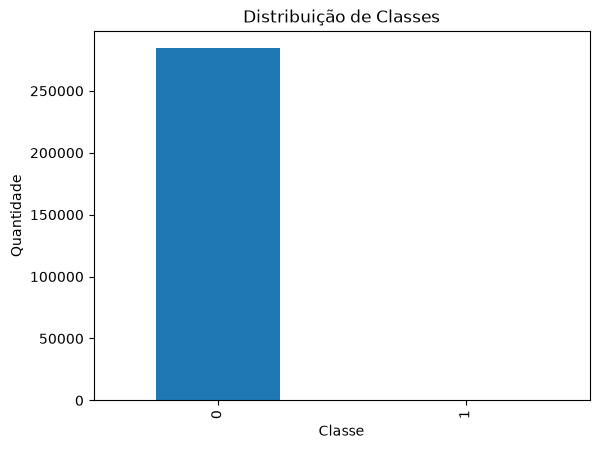

In [16]:
import matplotlib.pyplot as plt
df["Class"].value_counts().plot(kind="bar")
plt.title("Distribuição de Classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.show()

## Separação das variáveis

A variável `Class` será utilizada como variável target (`y`), pois representa a classe que o modelo deverá prever.

As demais variáveis serão utilizadas como características de entrada (`X`).

In [17]:
X = df.drop("Class", axis=1)
y= df["Class"]

In [18]:
X.shape

(284807, 30)

In [19]:
y.shape

(284807,)

## Separação entre treino e teste

Os dados são divididos em dois conjuntos:

- **Treino:** utilizado para aprender os padrões dos dados.
- **Teste:** utilizado posteriormente para avaliar o desempenho do modelo em dados que não participaram do treinamento.

Foi utilizada estratificação para preservar aproximadamente a mesma proporção entre transações normais e fraudulentas nos dois conjuntos.

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [21]:
X_train.shape

(227845, 30)

In [22]:
X_test.shape

(56962, 30)

In [23]:
y_train.shape

(227845,)

In [24]:
y_test.shape

(56962,)

In [25]:
y_train.value_counts()

Class
0    227451
1       394
Name: count, dtype: int64

In [26]:
y_test.value_counts()

Class
0    56864
1       98
Name: count, dtype: int64

## Padronização dos dados

Alguns algoritmos, como Logistic Regression e SVM, são sensíveis à escala das variáveis.

O `StandardScaler` transforma cada característica utilizando a média e o desvio padrão calculados a partir dos dados de treinamento.

O scaler é ajustado somente com `X_train` para evitar vazamento de informações do conjunto de teste.

### Observação

Modelos baseados em árvores, como Random Forest e Gradient Boosting, não dependem da mesma forma da escala das variáveis. Por isso, esses modelos foram treinados utilizando os dados originais.

In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
scaler = StandardScaler()

In [29]:
scaler.fit(X_train)

StandardScaler()

In [30]:
X_train_scaled = scaler.transform(X_train)

In [31]:
X_train_scaled.shape

(227845, 30)

In [32]:
comparacao = pd.DataFrame({
    "Original": X_train.iloc[0].values,
    "Padronizado": X_train_scaled[0]
}, index=X_train.columns)

comparacao

,Original,Padronizado
Time,161919.000000,1.411588
V1,1.946747,0.993379
V2,-0.752526,-0.456037
V3,-1.355130,-0.894052
V4,-0.661630,-0.467284
V5,1.502822,1.089217
V6,4.024933,3.024383
V7,-1.479661,-1.194852
V8,1.139880,0.957057
V9,1.406819,1.281376


In [33]:
X_test_scaled = scaler.transform(X_test)

In [34]:
X_test_scaled.shape

(56962, 30)

---------

## LOGISTIC REGRESSION

A Logistic Regression será utilizada como modelo inicial (baseline).

O objetivo é obter uma referência de desempenho para posteriormente comparar com modelos mais complexos.

In [35]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [36]:
y_pred = model.predict(X_test_scaled)

In [37]:
y_pred.shape

(56962,)

In [38]:
y_pred[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [39]:
pd.Series(y_pred).value_counts()

0    56887
1       75
Name: count, dtype: int64

## Métricas de avaliação

Como o dataset possui forte desbalanceamento entre as classes, a acurácia não é suficiente para avaliar o desempenho dos modelos.

Neste projeto, serão observadas principalmente:

- **Recall:** proporção das fraudes reais que foram identificadas.
- **Precision:** proporção das previsões de fraude que realmente eram fraudes.
- **F1-score:** equilíbrio entre precision e recall.

O recall recebe atenção especial porque deixar uma fraude passar representa um erro importante neste problema.

### Matriz de confusão

A matriz de confusão permite identificar quatro tipos de resultado:

- **True Positive (TP):** fraude corretamente identificada.
- **False Positive (FP):** transação normal classificada como fraude.
- **False Negative (FN):** fraude classificada como normal.
- **True Negative (TN):** transação normal corretamente identificada.

In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[56851,    13],
       [   36,    62]])

In [41]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print(f"{f1*100:.2f}%")

71.68%


In [42]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [43]:
y_prob[:20]

array([6.66589547e-05, 3.65855419e-05, 6.07869420e-06, 1.04140855e-04,
       7.65924761e-03, 2.28829338e-04, 5.12814321e-05, 1.41758870e-04,
       7.59584282e-04, 3.49946251e-05, 1.03467028e-03, 7.92210826e-05,
       3.56177259e-05, 6.43412759e-05, 9.02081552e-05, 1.60217831e-04,
       2.53855617e-05, 2.10965606e-05, 6.45209466e-05, 2.22683272e-03])

In [44]:
y_prob.max()

np.float64(0.9999999996310436)

### Threshold de classificação

Os modelos de classificação produzem uma probabilidade ou pontuação associada à classe positiva.

O threshold determina a partir de qual valor essa previsão será considerada fraude.

Neste projeto foram testados diferentes thresholds para observar o impacto sobre recall, precision e F1-score. Como os thresholds foram explorados utilizando o conjunto de teste, essa etapa deve ser interpretada como parte do estudo experimental. Em uma avaliação mais rigorosa, o threshold seria escolhido em um conjunto de validação separado e o conjunto de teste seria reservado para a avaliação final.

In [45]:
threshold = 0.30

y_pred_30 = (y_prob >= threshold).astype(int)

In [46]:
confusion_matrix(y_test, y_pred_30)

array([[56839,    25],
       [   30,    68]])

In [47]:
from sklearn.metrics import precision_score, recall_score
precision_score(y_test, y_pred_30)

0.7311827956989247

In [48]:
thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10]

resultados = []

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    recall = recall_score(y_test, y_pred_threshold)
    precision = precision_score(y_test, y_pred_threshold)

    resultados.append({
        "Threshold": threshold,
        "Recall": recall,
        "Precision": precision
    })

# Primeiro transforma a lista em DataFrame
resultados = pd.DataFrame(resultados)

# Agora podemos acessar as colunas
resultados["Recall"] = resultados["Recall"] * 100
resultados["Precision"] = resultados["Precision"] * 100

resultados

,Threshold,Recall,Precision
0,0.50,63.265306,82.666667
1,0.45,64.285714,80.769231
2,0.40,65.306122,75.294118
3,0.35,67.346939,74.157303
4,0.30,69.387755,73.118280
5,0.25,71.428571,72.916667
6,0.20,73.469388,73.469388
7,0.15,76.530612,72.815534
8,0.10,76.530612,70.093458


In [49]:
resultados = []

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    recall = recall_score(y_test, y_pred_threshold)
    precision = precision_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    resultados.append({
        "Threshold": threshold,
        "Recall": recall * 100,
        "Precision": precision * 100,
        "F1": f1 * 100
    })

resultados = pd.DataFrame(resultados)

resultados

,Threshold,Recall,Precision,F1
0,0.50,63.265306,82.666667,71.676301
1,0.45,64.285714,80.769231,71.590909
2,0.40,65.306122,75.294118,69.945355
3,0.35,67.346939,74.157303,70.588235
4,0.30,69.387755,73.118280,71.204188
5,0.25,71.428571,72.916667,72.164948
6,0.20,73.469388,73.469388,73.469388
7,0.15,76.530612,72.815534,74.626866
8,0.10,76.530612,70.093458,73.170732


In [50]:
threshold = 0.15

y_pred_15 = (y_prob >= threshold).astype(int)

cm_15 = confusion_matrix(y_test, y_pred_15)

cm_15

array([[56836,    28],
       [   23,    75]])

In [51]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_15))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.73      0.77      0.75        98

    accuracy                           1.00     56962
   macro avg       0.86      0.88      0.87     56962
weighted avg       1.00      1.00      1.00     56962



Nosso primeiro modelo ficou assim:

Logistic Regression + StandardScaler + threshold 0,15

TP = 75
FN = 23
FP = 28
TN = 56836

Recall    = 76,53%
Precision = 72,82%
F1        = 74,63%

### Análise dos resultados

A Logistic Regression apresentou desempenho limitado em relação aos modelos de árvores testados posteriormente. A alteração do threshold permitiu aumentar o recall, porém com impacto na precision.

----------------

## RANDOM FOREST

O Random Forest é um modelo baseado na combinação de diversas árvores de decisão.

O modelo foi treinado utilizando os dados originais, sem necessidade de padronização.

Após o treinamento, foram analisadas as probabilidades de fraude e diferentes thresholds.

### Análise dos resultados

O Random Forest apresentou, entre os modelos avaliados, uma combinação forte de recall, precision e F1-score nos experimentos realizados.

Entre os thresholds testados para o Random Forest, o valor de 0,40 apresentou o maior F1-score, com recall de 85,71% e precision de 93,33%.

Essa escolha foi feita sobre o conjunto de teste durante a exploração do projeto; portanto, o resultado deve ser interpretado como experimental, e não como uma avaliação final completamente independente.

In [52]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [53]:
rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [54]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [55]:
y_prob_rf[:20]

array([0.  , 0.  , 0.03, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ])

In [61]:
thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10]

resultados_rf = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_rf >= threshold).astype(int)

    recall = recall_score(y_test, y_pred_threshold)
    precision = precision_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    resultados_rf.append({
        "Threshold": threshold,
        "Recall": recall * 100,
        "Precision": precision * 100,
        "F1": f1 * 100
    })

resultados_rf = pd.DataFrame(resultados_rf)

resultados_rf

,Threshold,Recall,Precision,F1
0,0.50,81.632653,94.117647,87.431694
1,0.45,82.653061,93.103448,87.567568
2,0.40,85.714286,93.333333,89.361702
3,0.35,85.714286,89.361702,87.500000
4,0.30,87.755102,86.000000,86.868687
5,0.25,87.755102,81.904762,84.729064
6,0.20,87.755102,79.629630,83.495146
7,0.15,87.755102,78.181818,82.692308
8,0.10,88.775510,71.900826,79.452055


In [62]:
threshold = 0.40

y_pred_rf_40 = (y_prob_rf >= threshold).astype(int)

cm_rf_40 = confusion_matrix(y_test, y_pred_rf_40)

print(cm_rf_40)

[[56858     6]
 [   14    84]]


In [63]:
tn, fp, fn, tp = cm_rf_40.ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

print(f"Recall: {tp / (tp + fn) * 100:.2f}%")
print(f"Precision: {tp / (tp + fp) * 100:.2f}%")

TN: 56858
FP: 6
FN: 14
TP: 84
Recall: 85.71%
Precision: 93.33%


### Importância das características

O Random Forest permite analisar a importância relativa das características utilizadas nas decisões das árvores.

Essa análise ajuda a entender quais variáveis contribuíram mais para as decisões do modelo.

In [64]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
17,V17,0.170325
14,V14,0.136363
12,V12,0.133326
10,V10,0.074073
16,V16,0.071792
11,V11,0.045277
9,V9,0.031127
4,V4,0.030496
18,V18,0.028156
7,V7,0.024627


### Distribuição das principais características

As características V17, V14 e V12 apresentaram algumas das maiores importâncias no Random Forest.

Suas distribuições foram comparadas entre transações normais e fraudulentas para observar visualmente diferenças entre as classes.

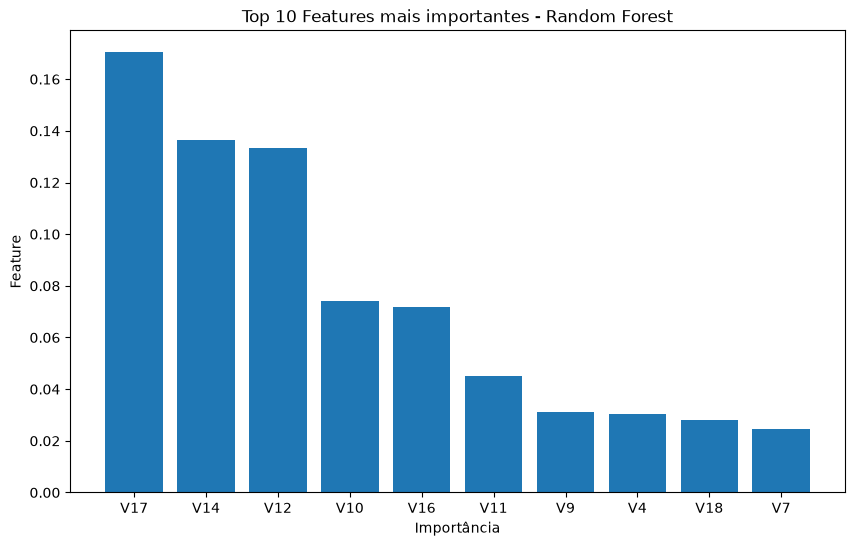

In [65]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importância")
plt.ylabel("Feature")
plt.title("Top 10 Features mais importantes - Random Forest")

plt.show()

In [66]:
normal = df[df["Class"] == 0]["V17"]
fraude = df[df["Class"] == 1]["V17"]

print("Normal:")
print(normal.describe())

print("\nFraude:")
print(fraude.describe())

Normal:
count    284315.000000
mean          0.011535
std           0.749457
min         -17.098444
25%          -0.482644
50%          -0.064833
75%           0.399922
max           9.253526
Name: V17, dtype: float64

Fraude:
count    492.000000
mean      -6.665836
std        6.970618
min      -25.162799
25%      -11.945057
50%       -5.302949
75%       -1.341940
max        6.739384
Name: V17, dtype: float64


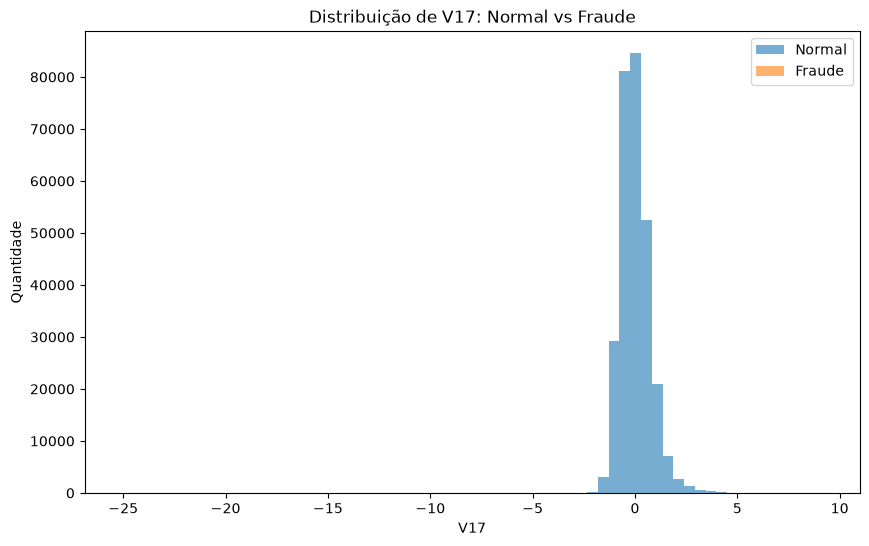

In [67]:
plt.figure(figsize=(10, 6))

plt.hist(normal, bins=50, alpha=0.6, label="Normal")
plt.hist(fraude, bins=50, alpha=0.6, label="Fraude")

plt.xlabel("V17")
plt.ylabel("Quantidade")
plt.title("Distribuição de V17: Normal vs Fraude")
plt.legend()

plt.show()

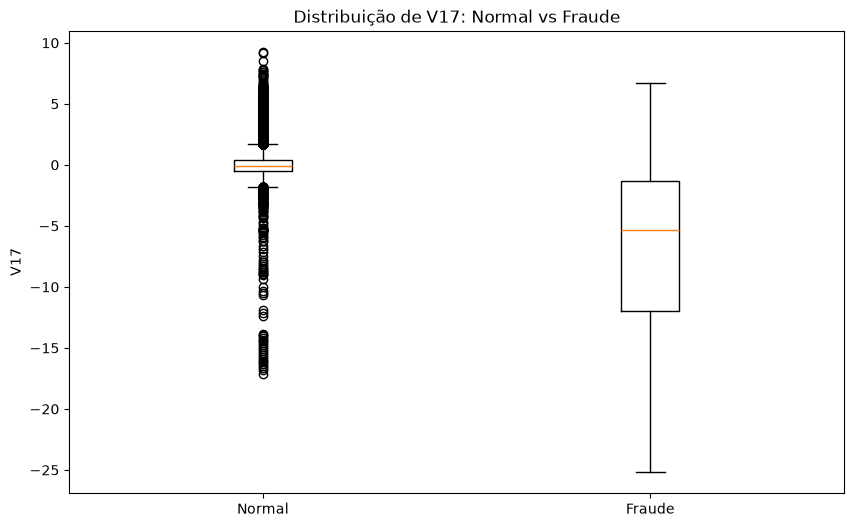

In [68]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    [normal, fraude],
    tick_labels= ["Normal", "Fraude"]
)

plt.ylabel("V17")
plt.title("Distribuição de V17: Normal vs Fraude")

plt.show()

In [69]:
normal_v14 = df[df["Class"] == 0]["V14"]
fraude_v14 = df[df["Class"] == 1]["V14"]

print("Normal:")
print(normal_v14.describe())

print("\nFraude:")
print(fraude_v14.describe())

Normal:
count    284315.000000
mean          0.012064
std           0.897007
min         -18.392091
25%          -0.422453
50%           0.051947
75%           0.494104
max          10.526766
Name: V14, dtype: float64

Fraude:
count    492.000000
mean      -6.971723
std        4.278940
min      -19.214325
25%       -9.692723
50%       -6.729720
75%       -4.282821
max        3.442422
Name: V14, dtype: float64


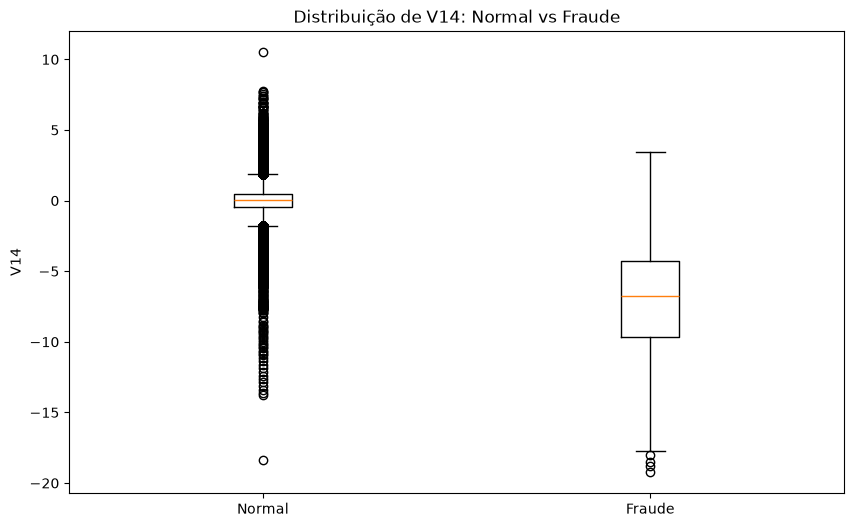

In [70]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    [normal_v14, fraude_v14],
    tick_labels=["Normal", "Fraude"]
)

plt.ylabel("V14")
plt.title("Distribuição de V14: Normal vs Fraude")

plt.show()

In [71]:
normal_v12 = df[df["Class"] == 0]["V12"]
fraude_v12 = df[df["Class"] == 1]["V12"]

print("Normal:")
print(normal_v12.describe())

print("\nFraude:")
print(fraude_v12.describe())

Normal:
count    284315.000000
mean          0.010832
std           0.945939
min         -15.144988
25%          -0.402102
50%           0.141679
75%           0.619207
max           7.848392
Name: V12, dtype: float64

Fraude:
count    492.000000
mean      -6.259393
std        4.654458
min      -18.683715
25%       -8.688177
50%       -5.502530
75%       -2.974088
max        1.375941
Name: V12, dtype: float64


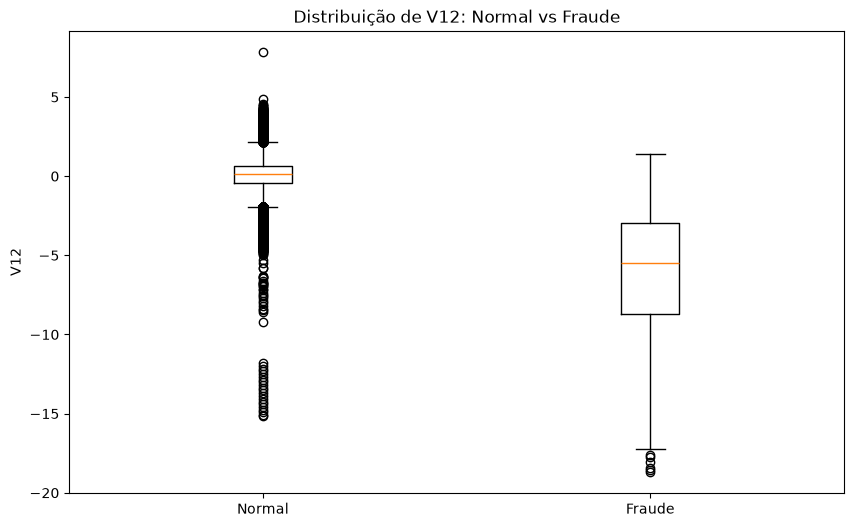

In [72]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    [normal_v12, fraude_v12],
    tick_labels=["Normal", "Fraude"]
)

plt.ylabel("V12")
plt.title("Distribuição de V12: Normal vs Fraude")

plt.show()

As distribuições apresentam diferenças entre as classes, embora exista sobreposição. Portanto, uma característica isolada não deve ser interpretada como uma regra direta para determinar se uma transação é fraudulenta.

-----

## Gradient Boosting Classifier

O Gradient Boosting foi testado como uma alternativa aos modelos anteriores.

Inicialmente foi avaliado seu desempenho com uma configuração padrão e posteriormente foi realizada uma pequena busca por hiperparâmetros.

In [73]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [74]:
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

In [75]:
y_prob_gb[:20]

array([0.00028655, 0.00028655, 0.00028655, 0.00028655, 0.00028655,
       0.00028655, 0.00028655, 0.00028655, 0.00028655, 0.00028655,
       0.00028655, 0.00028655, 0.00028655, 0.00028655, 0.00028655,
       0.00028655, 0.00028655, 0.00028655, 0.00028655, 0.00028655])

In [76]:
thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10]

resultados_gb = []

for threshold in thresholds:

    y_pred_gb = (y_prob_gb >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred_gb)

    tn, fp, fn, tp = cm.ravel()

    recall = tp / (tp + fn)
    precision = tp / (tp + fp)
    f1 = 2 * (precision * recall) / (precision + recall)

    resultados_gb.append({
        "Threshold": threshold,
        "Recall": recall * 100,
        "Precision": precision * 100,
        "F1": f1 * 100
    })

resultados_gb = pd.DataFrame(resultados_gb)

resultados_gb

,Threshold,Recall,Precision,F1
0,0.50,18.367347,52.941176,27.272727
1,0.45,18.367347,52.941176,27.272727
2,0.40,18.367347,52.941176,27.272727
3,0.35,18.367347,52.941176,27.272727
4,0.30,25.510204,59.523810,35.714286
5,0.25,25.510204,58.139535,35.460993
6,0.20,27.551020,50.943396,35.761589
7,0.15,27.551020,42.857143,33.540373
8,0.10,27.551020,29.670330,28.571429


In [79]:
import time

inicio = time.time()

gb_test = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)

gb_test.fit(X_train, y_train)

fim = time.time()

print(f"Tempo de treinamento: {(fim - inicio)/60:.2f} minutos")

Tempo de treinamento: 1.79 minutos


### Busca de hiperparâmetros

Foi utilizada uma busca limitada de hiperparâmetros devido ao custo computacional do treinamento do modelo.

O objetivo foi verificar se uma configuração diferente poderia melhorar o desempenho sem realizar uma busca excessivamente extensa.

A busca avaliou 8 combinações de hiperparâmetros com validação cruzada em 3 partes, totalizando 24 ajustes do modelo.

O `RandomizedSearchCV` foi configurado com `scoring="recall"`, portanto o `best_score_` representa o recall médio obtido na validação cruzada sobre o conjunto de treino, usando a regra de decisão padrão do classificador.

In [81]:
from sklearn.model_selection import RandomizedSearchCV

gb_model = GradientBoostingClassifier(
    random_state=42
)

param_dist = {
    "n_estimators": [50, 100],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3]
}

random_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_dist,
    n_iter=8,
    scoring="recall",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.05, 0.1], 'max_depth': [2, 3], 'n_estimators': [50, 100]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",8
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_result

In [82]:
print(random_search.best_params_)
print(random_search.best_score_)

{'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.1}
0.6089521165857044


In [84]:
best_gb_model = random_search.best_estimator_

y_prob_gb_tuned = best_gb_model.predict_proba(X_test)[:, 1]

In [85]:
thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10]

resultados_gb_tuned = []

for threshold in thresholds:

    y_pred = (y_prob_gb_tuned >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()

    recall = tp / (tp + fn)
    precision = tp / (tp + fp)

    if precision + recall > 0:
        f1 = 2 * (precision * recall) / (precision + recall)
    else:
        f1 = 0

    resultados_gb_tuned.append({
        "Threshold": threshold,
        "Recall": recall * 100,
        "Precision": precision * 100,
        "F1": f1 * 100
    })

resultados_gb_tuned = pd.DataFrame(resultados_gb_tuned)

resultados_gb_tuned

,Threshold,Recall,Precision,F1
0,0.50,7.142857,77.777778,13.084112
1,0.45,7.142857,77.777778,13.084112
2,0.40,7.142857,77.777778,13.084112
3,0.35,7.142857,77.777778,13.084112
4,0.30,7.142857,77.777778,13.084112
5,0.25,7.142857,77.777778,13.084112
6,0.20,7.142857,77.777778,13.084112
7,0.15,7.142857,77.777778,13.084112
8,0.10,7.142857,70.000000,12.962963


In [89]:
print("Mínimo:", y_prob_gb_tuned.min())
print("Máximo:", y_prob_gb_tuned.max())
print("Média:", y_prob_gb_tuned.mean())

print("\nMaiores probabilidades:")
print(np.sort(y_prob_gb_tuned)[-20:])

Mínimo: 0.0
Máximo: 1.0
Média: 0.0005714843437956022

Maiores probabilidades:
[0.02803097 0.02803097 0.02803097 0.02803097 0.02803097 0.02803097
 0.02803097 0.02803097 0.02803097 0.02803097 0.11507781 1.
 1.         1.         1.         1.         1.         1.
 1.         1.        ]


In [90]:
threshold = 0.10

y_pred_gb_tuned = (y_prob_gb_tuned >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_gb_tuned)

print(cm)

tn, fp, fn, tp = cm.ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

[[56861     3]
 [   91     7]]
TN: 56861
FP: 3
FN: 91
TP: 7


In [91]:
print("Quantidade de probabilidades exatamente 0:")
print(np.sum(y_prob_gb_tuned == 0))

print("\nQuantidade de probabilidades exatamente 1:")
print(np.sum(y_prob_gb_tuned == 1))

print("\nQuantidade acima de 0.10:")
print(np.sum(y_prob_gb_tuned >= 0.10))

print("\nQuantidade acima de 0.01:")
print(np.sum(y_prob_gb_tuned >= 0.01))

Quantidade de probabilidades exatamente 0:
93

Quantidade de probabilidades exatamente 1:
9

Quantidade acima de 0.10:
10

Quantidade acima de 0.01:
84


### Resultado

A configuração encontrada pela busca não apresentou desempenho competitivo no conjunto de teste. Além disso, o comportamento das probabilidades mostrou que a maior parte das previsões ficou concentrada em valores muito baixos, o que explica por que vários thresholds produziram exatamente os mesmos resultados.

Por esse motivo, não foram realizados novos ciclos extensos de otimização do Gradient Boosting.

----

## HistGradientBoosting

O HistGradientBoosting foi testado como uma variação do Gradient Boosting.

Assim como os demais modelos baseados em árvores, foi utilizado o conjunto de dados sem padronização.

O modelo apresentou recall intermediário, porém a redução do threshold aumentou pouco o recall e reduziu a precision de forma significativa.

In [92]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_model = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.1,
    max_leaf_nodes=31,
    random_state=42
)

hgb_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing val

In [93]:
y_prob_hgb = hgb_model.predict_proba(X_test)[:, 1]

In [94]:
y_prob_hgb[:20]

array([0.00061929, 0.00061929, 0.18440117, 0.00061929, 0.00040532,
       0.00061929, 0.00021568, 0.00061929, 0.00061929, 0.00061929,
       0.00063431, 0.00061929, 0.00022549, 0.00061929, 0.00061929,
       0.00061929, 0.00061929, 0.00061929, 0.00061929, 0.00060267])

In [97]:
from sklearn.metrics import recall_score, precision_score, f1_score

thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10]

for threshold in thresholds:
    y_pred_hgb = (y_prob_hgb >= threshold).astype(int)

    recall = recall_score(y_test, y_pred_hgb)
    precision = precision_score(y_test, y_pred_hgb)
    f1 = f1_score(y_test, y_pred_hgb)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Recall: {recall:.2%} | "
        f"Precision: {precision:.2%} | "
        f"F1: {f1:.2%}"
    )

Threshold: 0.50 | Recall: 73.47% | Precision: 54.55% | F1: 62.61%
Threshold: 0.45 | Recall: 74.49% | Precision: 52.52% | F1: 61.60%
Threshold: 0.40 | Recall: 74.49% | Precision: 49.32% | F1: 59.35%
Threshold: 0.35 | Recall: 74.49% | Precision: 48.99% | F1: 59.11%
Threshold: 0.30 | Recall: 74.49% | Precision: 47.40% | F1: 57.94%
Threshold: 0.25 | Recall: 74.49% | Precision: 43.45% | F1: 54.89%
Threshold: 0.20 | Recall: 74.49% | Precision: 42.69% | F1: 54.28%
Threshold: 0.15 | Recall: 74.49% | Precision: 41.71% | F1: 53.48%
Threshold: 0.10 | Recall: 75.51% | Precision: 40.88% | F1: 53.05%


----

## Support Vector Machine (SVM)

O SVM foi utilizado como outro algoritmo de classificação para comparação.

Como o SVM é sensível à escala das variáveis, foram utilizados os dados padronizados pelo StandardScaler.

O treinamento com kernel RBF apresentou custo computacional elevado devido ao tamanho do dataset.

In [98]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

C:\Users\kadek\PycharmProjects\Credit Card Fraud Detection\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [99]:
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]
y_prob_svm[:20]

array([0.00027668, 0.00036688, 0.00086951, 0.00038277, 0.00067873,
       0.00041508, 0.00021693, 0.00045972, 0.0004711 , 0.00049038,
       0.00143551, 0.00032708, 0.00043097, 0.00028857, 0.00056828,
       0.0003429 , 0.00036655, 0.00042771, 0.00035332, 0.00017611])

In [100]:
from sklearn.metrics import recall_score, precision_score, f1_score

thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10]

for threshold in thresholds:
    y_pred_svm = (y_prob_svm >= threshold).astype(int)

    recall = recall_score(y_test, y_pred_svm)
    precision = precision_score(y_test, y_pred_svm)
    f1 = f1_score(y_test, y_pred_svm)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Recall: {recall:.2%} | "
        f"Precision: {precision:.2%} | "
        f"F1: {f1:.2%}"
    )

Threshold: 0.50 | Recall: 77.55% | Precision: 95.00% | F1: 85.39%
Threshold: 0.45 | Recall: 77.55% | Precision: 95.00% | F1: 85.39%
Threshold: 0.40 | Recall: 77.55% | Precision: 95.00% | F1: 85.39%
Threshold: 0.35 | Recall: 77.55% | Precision: 95.00% | F1: 85.39%
Threshold: 0.30 | Recall: 77.55% | Precision: 95.00% | F1: 85.39%
Threshold: 0.25 | Recall: 77.55% | Precision: 95.00% | F1: 85.39%
Threshold: 0.20 | Recall: 78.57% | Precision: 93.90% | F1: 85.56%
Threshold: 0.15 | Recall: 78.57% | Precision: 93.90% | F1: 85.56%
Threshold: 0.10 | Recall: 78.57% | Precision: 93.90% | F1: 85.56%


> **Nota metodológica**
> Os thresholds apresentados foram explorados utilizando o conjunto de teste. Por isso, a comparação final deve ser interpretada como um estudo experimental. Para uma avaliação rigorosa, seria necessário separar treino, validação e teste, usar a validação para selecionar modelo e threshold e reservar o teste para a avaliação final.


# Comparação final dos modelos

### Análise dos resultados

O SVM apresentou alta precision e recall inferior ao Random Forest nos experimentos realizados.

A alteração do threshold teve pouco efeito na maior parte dos valores testados, indicando que as probabilidades produzidas pelo modelo estavam bastante concentradas.

Entre os thresholds testados, 0,20 apresentou o maior F1-score para o SVM.

In [101]:
results = pd.DataFrame({
    "Modelo": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "HistGradientBoosting",
        "SVM"
    ],
    "Threshold": [
        0.15,
        0.40,
        0.20,
        0.50,
        0.20
    ],
    "Recall": [
        76.53,
        85.71,
        27.55,
        73.47,
        78.57
    ],
    "Precision": [
        72.82,
        93.33,
        50.94,
        54.55,
        93.90
    ],
    "F1": [
        74.63,
        89.36,
        35.76,
        62.61,
        85.56
    ]
})

results

,Modelo,Threshold,Recall,Precision,F1
0,Logistic Regression,0.15,76.53,72.82,74.63
1,Random Forest,0.40,85.71,93.33,89.36
2,Gradient Boosting,0.30,25.51,59.52,35.71
3,HistGradientBoosting,0.50,73.47,54.55,62.61
4,SVM,0.20,78.57,93.90,85.56


## Modelo selecionado para análise final

Considerando o objetivo definido para este projeto e os experimentos realizados, o Random Forest com threshold de 0,40 foi utilizado como referência para a análise final.

Entre os thresholds avaliados para esse modelo, 0,40 apresentou o maior F1-score, mantendo recall elevado e precision alta.

- Recall: 85,71%
- Precision: 93,33%
- F1-score: 89,36%
- TP: 84
- FN: 14
- FP: 6
- TN: 56.858

> **Limitação metodológica:** o threshold foi escolhido após observar o desempenho no conjunto de teste. Em um pipeline mais rigoroso, essa decisão seria tomada em um conjunto de validação separado e o teste seria usado apenas uma vez para a avaliação final.

In [102]:
from sklearn.metrics import confusion_matrix

y_pred_rf_final = (y_prob_rf >= 0.40).astype(int)

cm_rf_final = confusion_matrix(y_test, y_pred_rf_final)

cm_rf_final

array([[56858,     6],
       [   14,    84]])

# Conclusão

Neste projeto foi desenvolvido um modelo de classificação para detecção de fraudes em transações de cartão de crédito, utilizando o dataset Credit Card Fraud Detection.

O principal desafio encontrado foi o forte desbalanceamento das classes. Das 284.807 transações, apenas 492 eram fraudulentas. Por esse motivo, a acurácia não foi utilizada como principal métrica de avaliação. O recall foi priorizado, pois representa a proporção de fraudes reais identificadas pelo modelo.

Foram testados cinco algoritmos:

- Logistic Regression
- Random Forest
- Gradient Boosting
- HistGradientBoosting
- SVM

A Logistic Regression foi utilizada como modelo inicial, servindo como baseline para comparação.

Considerando os experimentos realizados, o Random Forest com threshold de 0,40 foi utilizado como referência para a análise final. Entre os thresholds avaliados para esse modelo, esse valor apresentou o maior F1-score, com recall de 85,71%, precision de 93,33% e F1-score de 89,36%.

No conjunto de teste utilizado, o modelo identificou 84 das 98 transações fraudulentas, deixando de identificar 14. Também classificou 6 transações normais como fraude.

A análise das importâncias das variáveis do Random Forest mostrou que V17, V14 e V12 foram as características com maior importância para as decisões das árvores. Como as variáveis V1–V28 são componentes transformados e anonimizados do dataset original, não é possível atribuir a elas uma interpretação direta relacionada a características específicas das transações.

A análise dos thresholds mostrou que a alteração do ponto de decisão modifica o equilíbrio entre recall e precision. Thresholds menores tendem a classificar mais transações como fraude, podendo aumentar a quantidade de fraudes identificadas, mas também podem aumentar os falsos positivos.

Os resultados obtidos representam os experimentos realizados neste projeto e não devem ser interpretados como garantia de desempenho em um ambiente bancário real. Uma aplicação de produção exigiria uma estratégia de validação mais rigorosa, com separação explícita entre treino, validação e teste para seleção do modelo e do threshold, além da definição dos custos associados a falsos positivos e falsos negativos, monitoramento do modelo e reavaliação periódica de seu desempenho.

Assim, o projeto cumpre seu objetivo de comparar diferentes algoritmos e analisar como as escolhas de pré-processamento, métricas e threshold influenciam a detecção de fraudes.